In [8]:
import sqlite3

In [9]:
sqlite3.connect('ventas.db')

In [10]:
conexion = sqlite3.connect("ventas.db")
cursor = conexion.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS productos (
        id INTEGER PRIMARY KEY,
        nombre TEXT,
        categoria TEXT,
        precio REAL,
        stock INTEGER
    )
""")

cursor.executemany("""
    INSERT INTO productos (nombre, categoria, precio, stock)
    VALUES (?, ?, ?, ?)
""", [
    ("Notebook",    "tech",    320000, 5),
    ("Mouse",       "tech",    8500,   42),
    ("Escritorio",  "muebles", 85000,  3),
    ("Silla",       "muebles", 45000,  8),
    ("Monitor",     "tech",    210000, 0),
    ("Auriculares", "tech",    32000,  18),
    ("Lámpara",     "muebles", 12000,  25),
])

conexion.commit()

In [11]:
import pandas as pd

In [12]:
conexion = sqlite3.connect("ventas.db")

df = pd.read_sql("SELECT * FROM productos", conexion)
print(df)

   id       nombre categoria    precio  stock
0   1     Notebook      tech  320000.0      5
1   2        Mouse      tech    8500.0     42
2   3   Escritorio   muebles   85000.0      3
3   4        Silla   muebles   45000.0      8
4   5      Monitor      tech  210000.0      0
5   6  Auriculares      tech   32000.0     18
6   7      Lámpara   muebles   12000.0     25


In [13]:
df_tech = pd.read_sql(
    "SELECT * FROM productos WHERE categoria = 'tech'",
    conexion
)
print(df_tech)

   id       nombre categoria    precio  stock
0   1     Notebook      tech  320000.0      5
1   2        Mouse      tech    8500.0     42
2   5      Monitor      tech  210000.0      0
3   6  Auriculares      tech   32000.0     18


In [14]:
# Solo los productos con stock disponible, ordenados por precio
df_disponibles = pd.read_sql(
    "SELECT nombre, precio, stock FROM productos WHERE stock > 0 ORDER BY precio DESC",
    conexion)

print(df_disponibles)

        nombre    precio  stock
0     Notebook  320000.0      5
1   Escritorio   85000.0      3
2        Silla   45000.0      8
3  Auriculares   32000.0     18
4      Lámpara   12000.0     25
5        Mouse    8500.0     42


In [15]:
print(df.shape)

(7, 5)


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7 non-null      int64  
 1   nombre     7 non-null      str    
 2   categoria  7 non-null      str    
 3   precio     7 non-null      float64
 4   stock      7 non-null      int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 412.0 bytes


In [17]:
df.describe()

,id,precio,stock
count,7.000000,7.000000,7.000000
mean,4.000000,101785.714286,14.428571
std,2.160247,118650.697829,15.020621
min,1.000000,8500.000000,0.000000
25%,2.500000,22000.000000,4.000000
50%,4.000000,45000.000000,8.000000
75%,5.500000,147500.000000,21.500000
max,7.000000,320000.000000,42.000000


In [18]:
print(df)


   id       nombre categoria    precio  stock
0   1     Notebook      tech  320000.0      5
1   2        Mouse      tech    8500.0     42
2   3   Escritorio   muebles   85000.0      3
3   4        Silla   muebles   45000.0      8
4   5      Monitor      tech  210000.0      0
5   6  Auriculares      tech   32000.0     18
6   7      Lámpara   muebles   12000.0     25


In [20]:
#Supongamos que queremos saber cuántos productos pertenecen a cada categoría.

df["categoria"].value_counts()


categoria
tech       4
muebles    3
Name: count, dtype: int64

In [26]:
import matplotlib.pyplot as plt

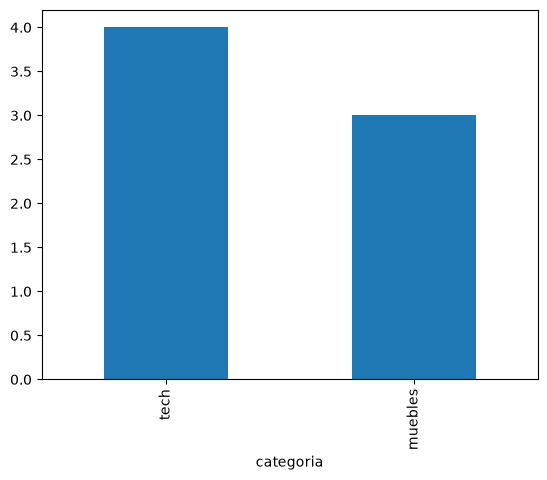

In [27]:
df["categoria"].value_counts().plot(kind="bar")

plt.show()

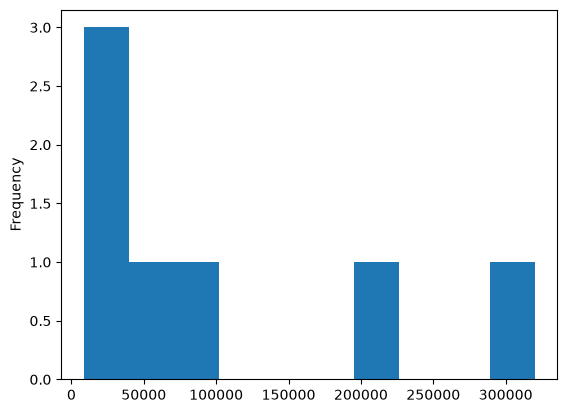

In [28]:
df["precio"].plot(kind="hist")

plt.show()